# California Housing - Complete House Price Prediction Lab
Follows the MDI3003 workflow using the California Housing dataset.

In [1]:
!pip install scikit-learn joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED=42
np.random.seed(SEED)


## Step 1 - Load Dataset

In [2]:
housing=fetch_california_housing(as_frame=True)
df=housing.frame.rename(columns={'MedHouseVal':'Price'})
target='Price'
display(df.head())
print(df.shape)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


(20640, 9)


## Step 2 - Data Audit

In [3]:
display(df.describe())
print(df.isna().sum())
print("Duplicates:",df.duplicated().sum())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64
Duplicates: 0


## Step 3 - Train Test Split

In [4]:
X=df.drop(columns=[target]); y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=SEED)

## Step 4 - EDA

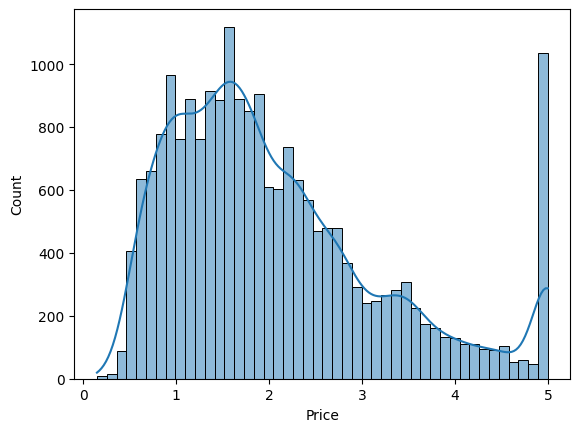

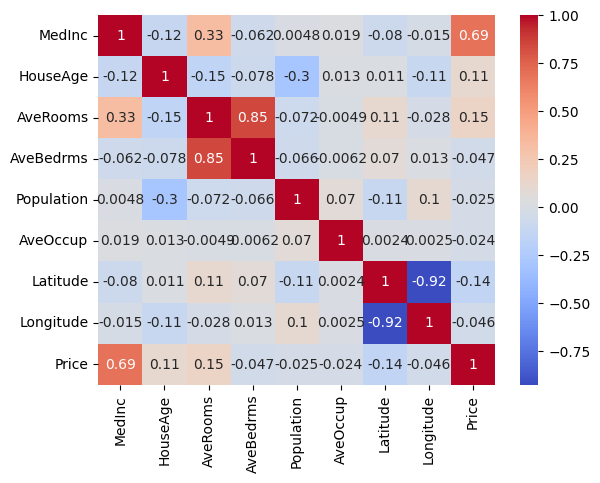

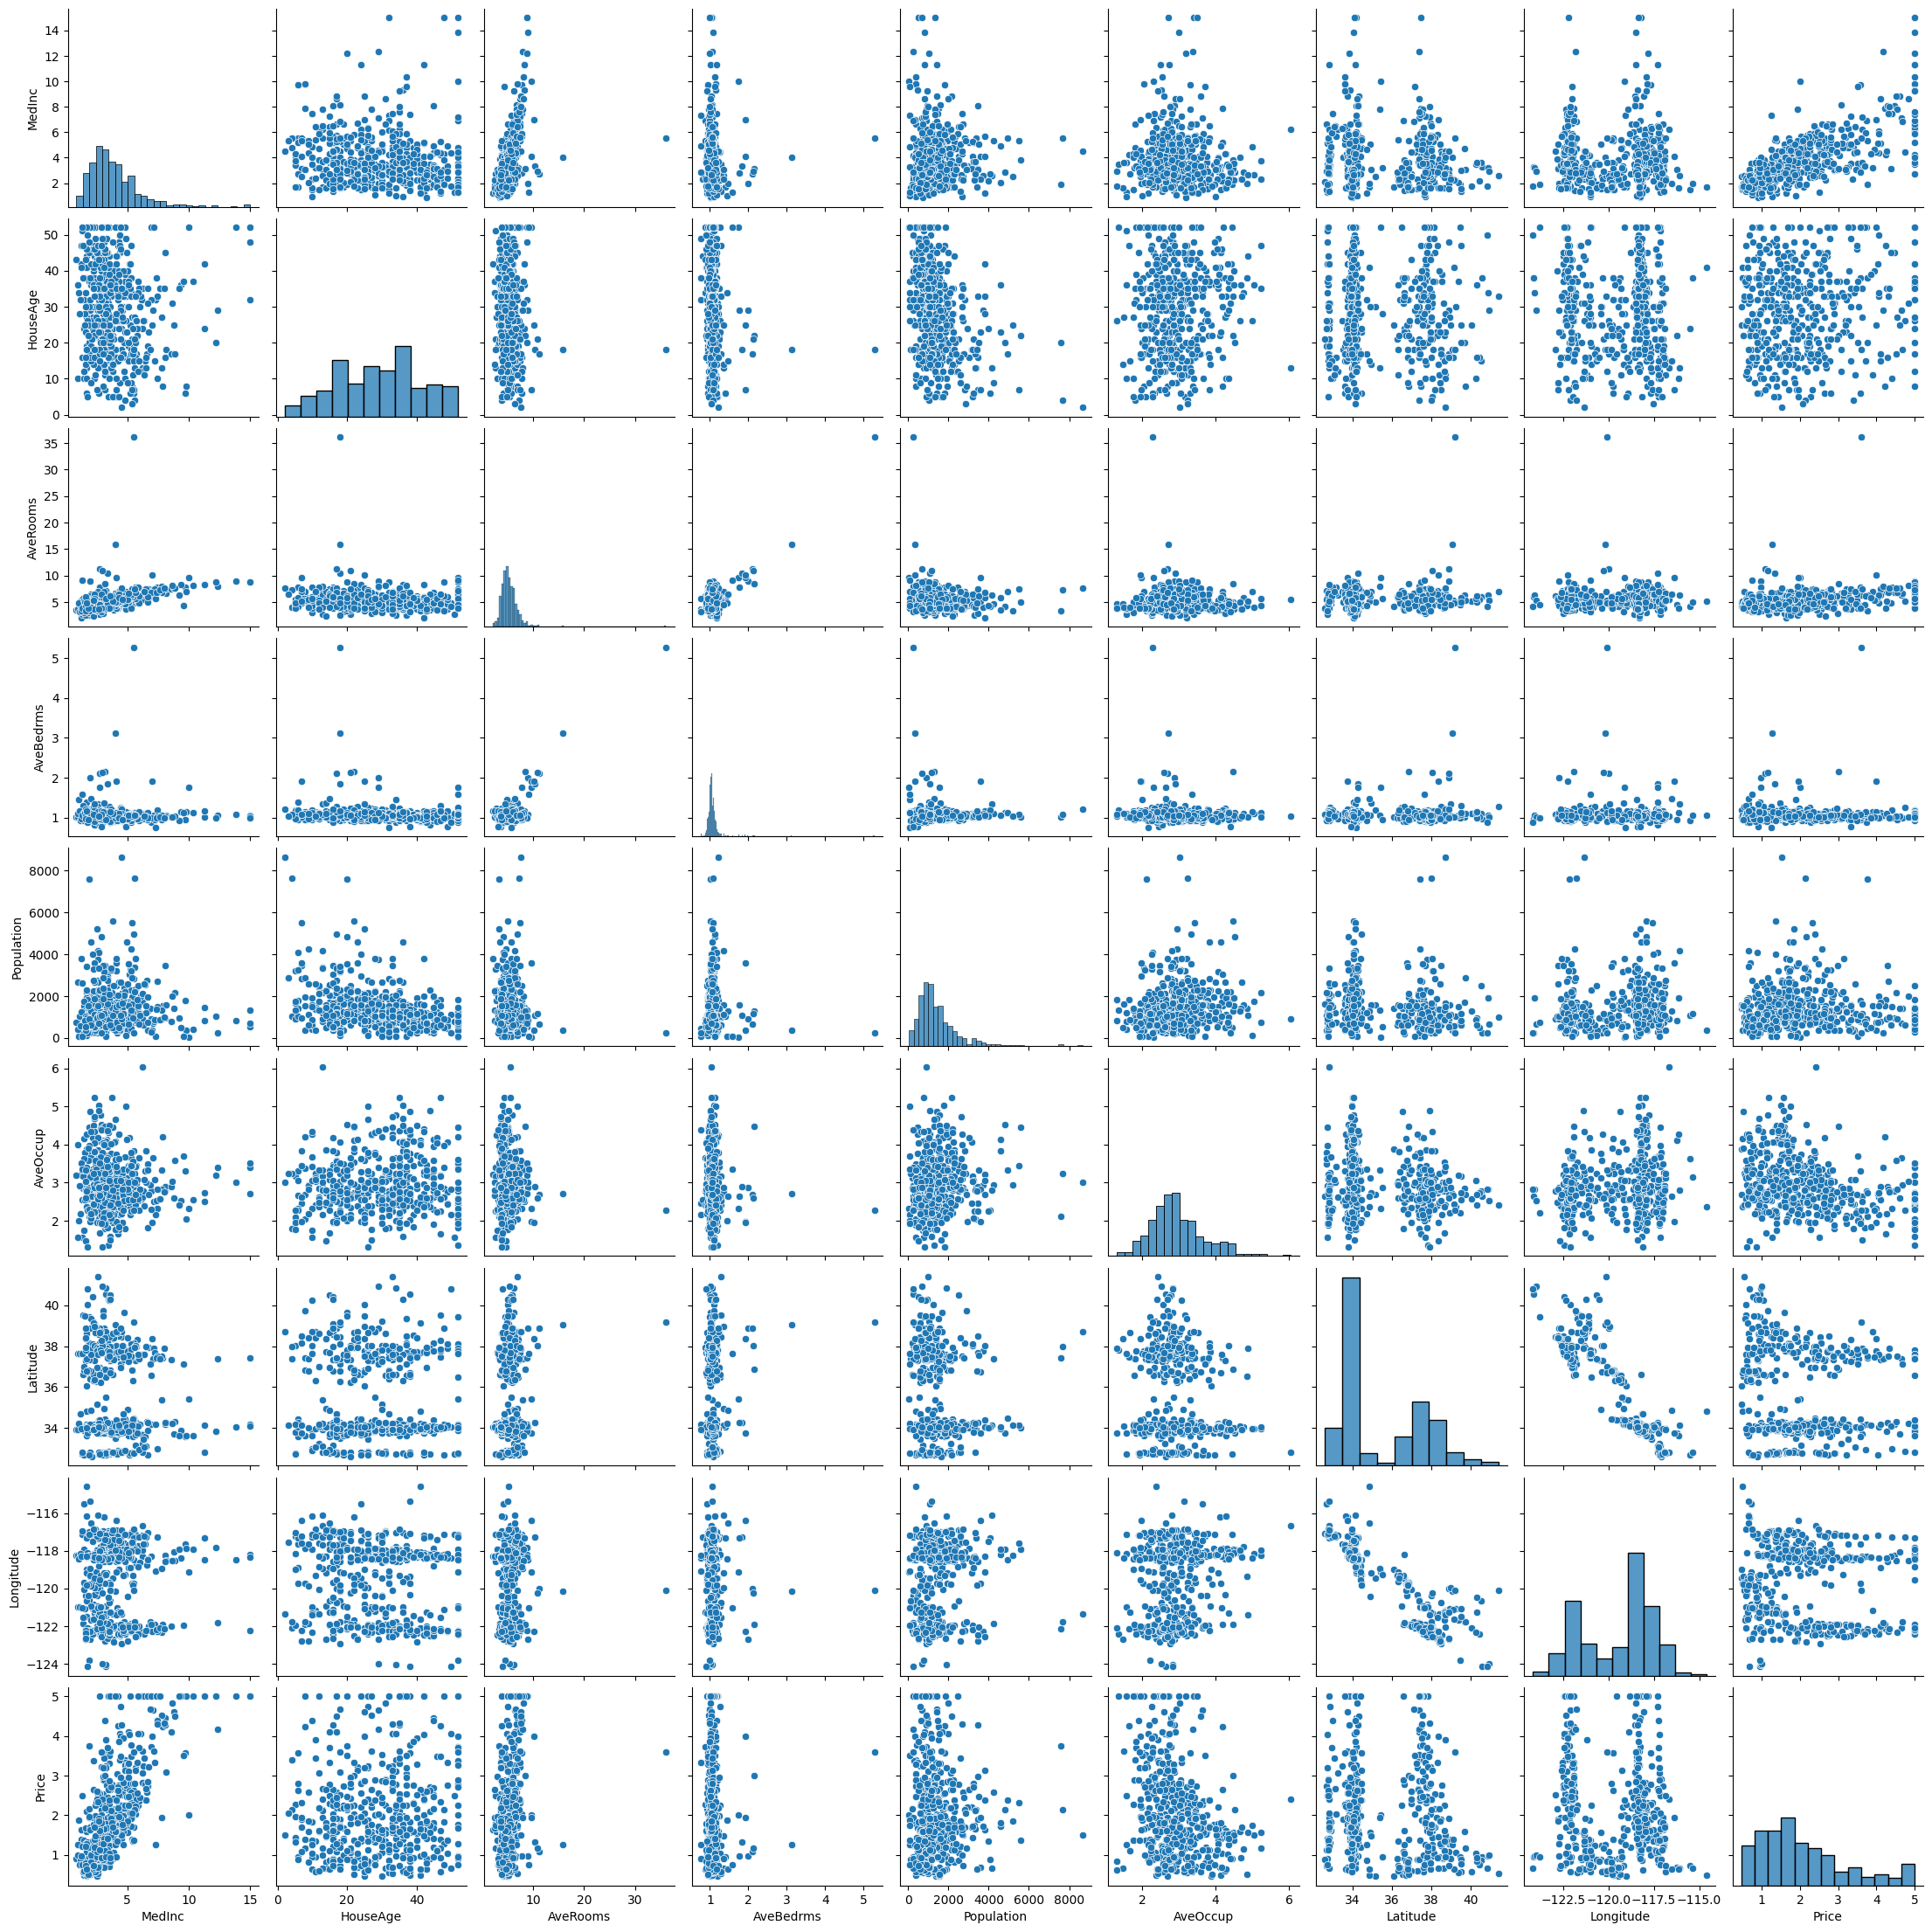

In [5]:
sns.histplot(y,kde=True); plt.show()
sns.heatmap(df.corr(),annot=True,cmap='coolwarm'); plt.show()
sns.pairplot(df.sample(500,random_state=SEED)); plt.show()

## Step 5 - Preprocessing

In [6]:
num=X_train.columns
preprocess=ColumnTransformer([
('num',Pipeline([
('imp',SimpleImputer(strategy='median')),
('sc',StandardScaler())
]),num)
])

## Step 6 - Dummy Baseline

In [7]:
dummy=DummyRegressor()
dummy.fit(X_train,y_train)
pred=dummy.predict(X_test)
print("MAE",mean_absolute_error(y_test,pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,pred)))

MAE 0.9060685490007149
RMSE 1.1448563543099792


## Step 7 - Simple Linear Regression

Slope 0.4193384939381271
Intercept 0.4445972916907879


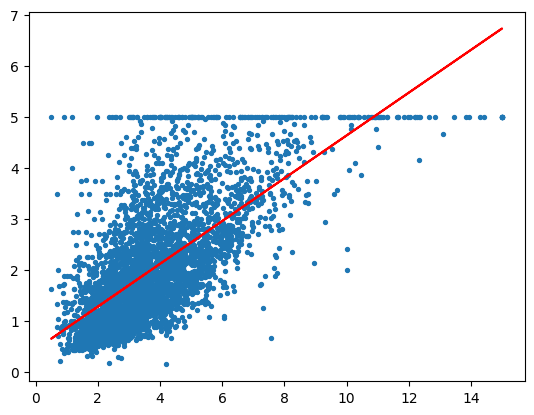

In [8]:
feature='MedInc'
slr=LinearRegression()
slr.fit(X_train[[feature]],y_train)
pred=slr.predict(X_test[[feature]])
print("Slope",slr.coef_[0])
print("Intercept",slr.intercept_)
plt.scatter(X_test[feature],y_test,s=8)
plt.plot(X_test[feature],pred,color='red')
plt.show()

## Step 8-13 Model Comparison

In [9]:
models={
'Linear':LinearRegression(),
'Ridge':Ridge(),
'Lasso':Lasso(max_iter=10000),
'ElasticNet':ElasticNet(max_iter=10000),
'DecisionTree':DecisionTreeRegressor(random_state=SEED),
'RandomForest':RandomForestRegressor(random_state=SEED),
'GradientBoosting':GradientBoostingRegressor(random_state=SEED)
}
rows=[]
for name,m in models.items():
    pipe=Pipeline([('prep',preprocess),('model',m)])
    pipe.fit(X_train,y_train)
    p=pipe.predict(X_test)
    rows.append([name,
                 mean_absolute_error(y_test,p),
                 np.sqrt(mean_squared_error(y_test,p)),
                 r2_score(y_test,p)])
results=pd.DataFrame(rows,columns=['Model','MAE','RMSE','R2']).sort_values('RMSE')
display(results)

,Model,MAE,RMSE,R2
5,RandomForest,0.327425,0.505143,0.805275
6,GradientBoosting,0.371650,0.542217,0.775643
4,DecisionTree,0.453904,0.702829,0.623042
1,Ridge,0.533193,0.745557,0.575816
0,Linear,0.533200,0.745581,0.575788
3,ElasticNet,0.805995,1.021876,0.203126
2,Lasso,0.906069,1.144856,-0.000219


## Step 14 - Cross Validation

In [10]:
cv=KFold(n_splits=5,shuffle=True,random_state=SEED)
pipe=Pipeline([('prep',preprocess),('model',Ridge())])
scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring='neg_root_mean_squared_error')
print("CV RMSE",-scores['test_score'].mean())

CV RMSE 0.7205090731464323


## Step 15 - GridSearchCV

In [11]:
grid=GridSearchCV(pipe,{'model__alpha':[0.01,0.1,1,10,100]},cv=5,
scoring='neg_root_mean_squared_error')
grid.fit(X_train,y_train)
best_model=grid.best_estimator_
print(grid.best_params_)

{'model__alpha': 0.01}


## Step 16 - Polynomial Regression

In [12]:
poly=Pipeline([
('poly',PolynomialFeatures(degree=2,include_bias=False)),
('sc',StandardScaler()),
('ridge',Ridge())
])
poly.fit(X_train[['MedInc','AveRooms','HouseAge']],y_train)
poly_pred=poly.predict(X_test[['MedInc','AveRooms','HouseAge']])
print("Polynomial RMSE",np.sqrt(mean_squared_error(y_test,poly_pred)))

Polynomial RMSE 0.8012482185883876


## Step 17 - Residual Analysis

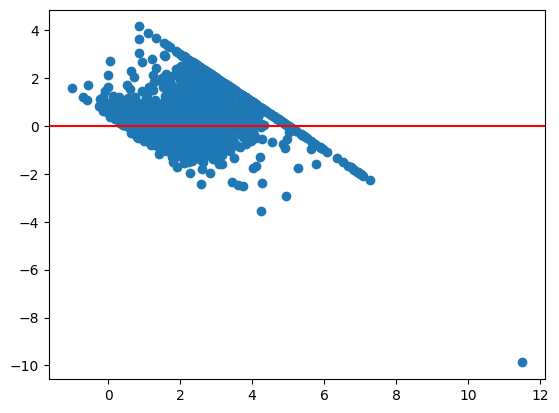

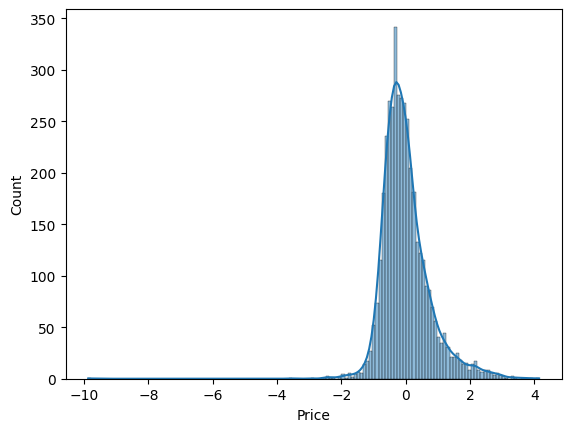

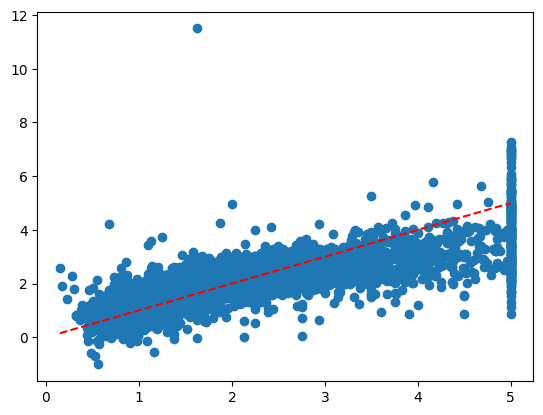

In [13]:
pred=best_model.predict(X_test)
res=y_test-pred
plt.scatter(pred,res)
plt.axhline(0,color='red')
plt.show()
sns.histplot(res,kde=True)
plt.show()
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()

## Step 18 - Save Model

In [14]:
joblib.dump(best_model,'california_house_pipeline.joblib')
results.to_csv('model_comparison.csv',index=False)
with open('metadata.json','w') as f:
    json.dump({'dataset':'California Housing','seed':42},f,indent=2)
print("Completed.")

Completed.
